# Testing BiomedParse

## Dependencies, Constants, and Helper Functions

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch
import torch.nn.functional as F
import hydra
from hydra import compose
from hydra.core.global_hydra import GlobalHydra
from utils import process_input, process_output
from inference import postprocess, merge_multiclass_masks
from workflow.scripts.evaluate import Evaluator

from skimage import segmentation
from skimage.measure import label

/home/bhkuser/bhklab/kaitlyn/bhklab-BiomedParse/.pixi/envs/default/lib/python3.10/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/home/bhkuser/bhklab/kaitlyn/bhklab-BiomedParse/.pixi/envs/default/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Failure while loading azureml_run_type_providers. Failed to load entrypoint azureml.scriptrun = azureml.core.script_run:ScriptRun._from_run_dto with exception The 'ruamel.yaml>=0.15.35' distribution was not found and is required by the application.


In [2]:
def find_first_last_slice(mask): 
    axes = tuple([i for i in range(mask.ndim) if i != 0])

    slices = mask.any(axis = axes) 

    nonzero_indices = np.where(slices)[0]

    first_slice = np.amin(nonzero_indices)
    last_slice = np.amax(nonzero_indices) 

    return first_slice, last_slice

def get_recist_line_coords(recist_arr): 
    first, _ = find_first_last_slice(recist_arr) #Should only have one slice with non-zero elements --> only need first slice
    
    non_zero_idxs = np.argwhere(recist_arr[first])

    if non_zero_idxs.size < 1: 
        print("No annotation found, please check previous preprocessing steps.")
    else:
        first_coord = non_zero_idxs[0]
        last_coord = non_zero_idxs[-1]

        print(f"First Point: {first_coord}")
        print(f"Last Point: {last_coord}")
        print(f"Slice Number: {first}")

        return first_coord, last_coord, first
    
def list_nonzero_seg_slices(seg): 
    nonzero_slices = []
    for slice_idx in range(seg.shape[0]): 
        if np.count_nonzero(seg[slice_idx]) > 0: 
            nonzero_slices.append(slice_idx)
    return nonzero_slices

def get_hist_data(seg): 
    pix_slice_dict = dict() 
    for slice_idx in range(seg.shape[0]): 
        pix_count = np.count_nonzero(seg[slice_idx]) 
        pix_slice_dict[slice_idx] = pix_count

    return pix_slice_dict

def get_hist_data_df(seg): 
    pix_slice_dict = {
        'slice_num': [],
        'pix_count': []
    }
    for slice_idx in range(seg.shape[0]): 
        pix_count = np.count_nonzero(seg[slice_idx]) 
        pix_slice_dict['slice_num'].append(slice_idx) 
        pix_slice_dict['pix_count'].append(pix_count) 

    data = pd.DataFrame(pix_slice_dict)

    return data


## Load Model

### Load BiomedParse Model

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

GlobalHydra.instance().clear()
hydra.initialize(config_path="configs/model", job_name="example_prediction")
cfg = compose(config_name="biomedparse_3D")
model = hydra.utils.instantiate(cfg, _convert_="object")
model.load_pretrained('/home/bhkuser/bhklab/kaitlyn/bhklab-BiomedParse/config/biomedparse_v2.ckpt')
model = model.to(device).eval()

Using device: cpu


/tmp/ipykernel_989205/2970445561.py:5: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  hydra.initialize(config_path="configs/model", job_name="example_prediction")
/home/bhkuser/bhklab/kaitlyn/bhklab-BiomedParse/.pixi/envs/default/lib/python3.10/site-packages/hydra/_internal/defaults_list.py:251: UserWarning: In 'biomedparse_3D': Defaults list is missing `_self_`. See https://hydra.cc/docs/1.2/upgrades/1.0_to_1.1/default_composition_order for more information
  warnings.warn(msg, UserWarning)
/home/bhkuser/bhklab/kaitlyn/bhklab-BiomedParse/.pixi/envs/default/lib/python3.10/site-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Checkpoint loaded successfully!


In [ ]:
#If downloading from huggingface for the first time, use this
from huggingface_hub import hf_hub_download

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

GlobalHydra.instance().clear()
hydra.initialize(config_path="configs/model", job_name="example_prediction")
cfg = compose(config_name="biomedparse_3D")
model = hydra.utils.instantiate(cfg, _convert_="object")
ckpt_file = hf_hub_download(repo_id="microsoft/BiomedParse", filename="biomedparse_v2.ckpt")
print(ckpt_file)
model.load_pretrained(ckpt_file)
model = model.to(device).eval()

## Test Run on Example Case

### On non-isotropic data

In [ ]:
#Get data into specified format
former_npz_path = "/home/bhkuser/bhklab/kaitlyn/recist-vs-reality/data/procdata/Abdomen/TCIA_CPTAC-CCRCC/images/npz_TCIA_CPTAC-CCRCC/C3N-00194_0035_RTSTRUCT_210218.4_0.npz"
former_npz = np.load(former_npz_path, allow_pickle = True) 

image = former_npz['imgs']
text_prompts = {'1': 'x = 350, y = 300, z = 20', 'instance_label': 0}
gt_masks = former_npz['gts']

In [ ]:
ids = [int(_) for _ in text_prompts.keys() if _ != "instance_label"]
ids.sort()
text = "[SEP]".join([text_prompts[str(i)] for i in ids])

imgs, pad_width, padded_size, valid_axis = process_input(image, 512)

imgs = imgs.to(device).int()

input_tensor = {
    "image": imgs.unsqueeze(0),  # Add batch dimension
    "text": [text],
}

In [ ]:
with torch.no_grad():
    output = model(input_tensor, mode="eval", slice_batch_size=4)

mask_preds = output["predictions"]["pred_gmasks"]
mask_preds = F.interpolate(mask_preds, size=(512, 512), mode="bicubic", align_corners=False, antialias=True)

mask_preds = postprocess(mask_preds, output["predictions"]["object_existence"])
mask_preds = merge_multiclass_masks(mask_preds, ids)
mask_preds = process_output(mask_preds, pad_width, padded_size, valid_axis)
print("Processed mask shape:", mask_preds.shape)

In [ ]:
print(image.shape)
print(gt_masks.shape)
print(mask_preds.shape)

In [ ]:
slice_id = 20
slice_image = image[slice_id]
slice_mask = mask_preds[slice_id]
slice_gt   = gt_masks[slice_id]

# rotate = 2
# slice_image = np.rot90(slice_image, k=rotate)
# slice_gt = np.rot90(slice_gt, k=rotate)
# slice_mask = np.rot90(slice_mask, k=rotate)

# flip = True
# if flip:
#     slice_image = np.flip(slice_image, axis=1)
#     slice_gt = np.flip(slice_gt, axis=1)
#     slice_mask = np.flip(slice_mask, axis=1)

# if text_prompts['instance_label'] == 1:
#     # If instance_label is 1, we assume it is a binary mask
#     slice_gt   = slice_gt > 0

# 1) Compute the mapping
unique_ids = np.unique(np.concatenate((slice_mask, slice_gt)))
id_map = {orig_id: new_i for new_i, orig_id in enumerate(unique_ids)}

slice_mask_mapped = np.vectorize(id_map.get)(slice_mask)
slice_gt_mapped   = np.vectorize(id_map.get)(slice_gt)

slice_mask_mapped = np.ma.masked_where(slice_mask_mapped == 0, slice_mask_mapped)
slice_gt_mapped = np.ma.masked_where(slice_gt_mapped == 0, slice_gt_mapped)

# 2) Which IDs to show (drop background=0)
mask_ids = unique_ids[1:]

# 3) Labels for legend
legends = [text_prompts[str(i)] for i in mask_ids if str(i) in text_prompts]
mask_ids = [i for i in mask_ids if str(i) in text_prompts]

# 4) Build a *discrete* colormap of size len(unique_ids)
#    so that cmap(k) gives exactly the k-th color.
cmap = plt.get_cmap('tab20', len(unique_ids)-1)

# 5) Create handles using integer lookup into the discrete cmap
handles = [
    mpatches.Patch(color=cmap(id_map[i]-1), label=txt)
    for i, txt in zip(mask_ids, legends)
]

# 6) Plot
fig, axes = plt.subplots(1, 3, figsize=(8, 3))

axes[0].imshow(slice_image, cmap="gray")
axes[0].set_title("Original Image Slice")
axes[0].axis("off")

axes[1].imshow(slice_image, cmap='gray')
axes[1].imshow(slice_gt_mapped, cmap=cmap, interpolation='nearest', alpha = 0.6)
axes[1].set_title("Ground Truth Masks")
axes[1].axis("off")

axes[2].imshow(slice_image, cmap='gray')
axes[2].imshow(slice_mask_mapped, cmap=cmap, interpolation='nearest', alpha = 0.6)
axes[2].set_title("Predicted Masks")
axes[2].axis("off")

# 7) Shared legend below, single column
fig.legend(handles, legends, loc='lower center', bbox_to_anchor=(0.29, -0.15), ncol=1, frameon=False, fontsize=11)

plt.tight_layout()
plt.subplots_adjust(bottom=0)
plt.show()

In [ ]:
def find_first_last_slice(mask): 
    axes = tuple([i for i in range(mask.ndim) if i != 0])

    slices = mask.any(axis = axes) 

    nonzero_indices = np.where(slices)[0]

    first_slice = np.amin(nonzero_indices)
    last_slice = np.amax(nonzero_indices) 

    return first_slice, last_slice

### On 1 mm isotropic data

In [ ]:
from imgtools.transforms.functional import resample 
import SimpleITK as sitk
#Get data into specified format
former_npz_path = "/home/bhkuser/bhklab/kaitlyn/recist-vs-reality/data/procdata/Abdomen/TCIA_CPTAC-CCRCC/images/npz_TCIA_CPTAC-CCRCC/C3N-00194_0035_RTSTRUCT_210218.4_0.npz"
former_npz = np.load(former_npz_path, allow_pickle = True) 

image_orig = former_npz['imgs']
img = sitk.GetImageFromArray(image_orig)
resamp_img = resample(image = img, 
                      spacing = 1, 
                      interpolation = 'nearest')

image = sitk.GetArrayFromImage(resamp_img)

text_prompts = {'1': 'Presence of kidney lesion detected in CT imaging', 'instance_label': 0}

gt_masks_orig = former_npz['gts']
seg = sitk.GetImageFromArray(gt_masks_orig)
resamp_seg = resample(image = seg, 
                      spacing = 1, 
                      interpolation = 'nearest') 
resamp_seg = sitk.Cast(resamp_seg, sitk.sitkUInt8)

gt_masks = sitk.GetArrayFromImage(resamp_seg)

In [ ]:
ids = [int(_) for _ in text_prompts.keys() if _ != "instance_label"]
ids.sort()
text = "[SEP]".join([text_prompts[str(i)] for i in ids])

imgs, pad_width, padded_size, valid_axis = process_input(image, 512)

imgs = imgs.to(device).int()

input_tensor = {
    "image": imgs.unsqueeze(0),  # Add batch dimension
    "text": [text],
}

In [ ]:
with torch.no_grad():
    output = model(input_tensor, mode="eval", slice_batch_size=4)

mask_preds = output["predictions"]["pred_gmasks"]
mask_preds = F.interpolate(mask_preds, size=(512, 512), mode="bicubic", align_corners=False, antialias=True)

mask_preds = postprocess(mask_preds, output["predictions"]["object_existence"])
mask_preds = merge_multiclass_masks(mask_preds, ids)
mask_preds = process_output(mask_preds, pad_width, padded_size, valid_axis)
print("Processed mask shape:", mask_preds.shape)

In [ ]:
slice_id = 44
slice_image = image[slice_id]
slice_mask = mask_preds[slice_id]
slice_gt   = gt_masks[slice_id]

rotate = 2
slice_image = np.rot90(slice_image, k=rotate)
slice_gt = np.rot90(slice_gt, k=rotate)
slice_mask = np.rot90(slice_mask, k=rotate)

flip = True
if flip:
    slice_image = np.flip(slice_image, axis=1)
    slice_gt = np.flip(slice_gt, axis=1)
    slice_mask = np.flip(slice_mask, axis=1)

if text_prompts['instance_label'] == 1:
    # If instance_label is 1, we assume it is a binary mask
    slice_gt   = slice_gt > 0

# 1) Compute the mapping
unique_ids = np.unique(np.concatenate((slice_mask, slice_gt)))
id_map = {orig_id: new_i for new_i, orig_id in enumerate(unique_ids)}

slice_mask_mapped = np.vectorize(id_map.get)(slice_mask)
slice_gt_mapped   = np.vectorize(id_map.get)(slice_gt)

slice_mask_mapped = np.ma.masked_where(slice_mask_mapped == 0, slice_mask_mapped)
slice_gt_mapped = np.ma.masked_where(slice_gt_mapped == 0, slice_gt_mapped)

# 2) Which IDs to show (drop background=0)
mask_ids = unique_ids[1:]

# 3) Labels for legend
legends = [text_prompts[str(i)] for i in mask_ids if str(i) in text_prompts]
mask_ids = [i for i in mask_ids if str(i) in text_prompts]

# 4) Build a *discrete* colormap of size len(unique_ids)
#    so that cmap(k) gives exactly the k-th color.
cmap = plt.get_cmap('tab20', len(unique_ids)-1)

# 5) Create handles using integer lookup into the discrete cmap
handles = [
    mpatches.Patch(color=cmap(id_map[i]-1), label=txt)
    for i, txt in zip(mask_ids, legends)
]

# 6) Plot
fig, axes = plt.subplots(1, 3, figsize=(8, 5))

axes[0].imshow(slice_image, cmap="gray")
axes[0].set_title("Original Image Slice")
axes[0].axis("off")

axes[1].imshow(slice_image, cmap='gray', alpha=0.4)
axes[1].imshow(slice_gt_mapped, cmap=cmap, interpolation='nearest')
axes[1].set_title("Ground Truth Masks")
axes[1].axis("off")

axes[2].imshow(slice_image, cmap='gray', alpha=0.4)
axes[2].imshow(slice_mask_mapped, cmap=cmap, interpolation='nearest')
axes[2].set_title("Predicted Masks")
axes[2].axis("off")

# 7) Shared legend below, single column
fig.legend(handles, legends, loc='lower center', bbox_to_anchor=(0.4, -0.15), ncol=1, frameon=False, fontsize=11)

plt.tight_layout()
plt.subplots_adjust(bottom=0)
plt.show()

## Prompt Testing

### Load in test case

In [4]:
test_case_path = "/home/bhkuser/bhklab/kaitlyn/recist-vs-reality/data/procdata/Abdomen/TCIA_CPTAC-CCRCC/images/npz_TCIA_CPTAC-CCRCC/C3N-00194_0035_RTSTRUCT_210218.4_0.npz"
test_case = np.load(test_case_path, allow_pickle = True) 

recist = test_case['recist']
image = test_case['imgs']
gt = test_case['gts']

### Get RECIST Coordinate Information

In [5]:
# Get coordinates that define recist line
coord1, coord2, slice_num = get_recist_line_coords(recist_arr = recist)

# Get midpoint 
coord_mid = [int((coord1[0] + coord2[0]) / 2), int((coord1[1] + coord2[1]) / 2)]
print(f"RECIST Line MidPoint: {coord_mid}")

First Point: [241 363]
Last Point: [323 338]
Slice Number: 44
RECIST Line MidPoint: [282, 350]


### Create multiple prompts 

In [167]:
# Control cases (no instances of tumours should be in this section of the image) 
ctrl_coord = {'1': 'x = 0, y = 0, z = 0', 'instance_label': 0}
ctrl_line = {'1': 'x1 = 0, y1 = 0, z1 = 0, x2 = 25, y2 = 25, z2 = 0', 'instance_label': 0}
ctrl_line2 = {'1': '(0, 0, 0), (0, 25, 25)', 'instance_label': 0} #Assumes that the model is interpretting images in the same way they are inputted in (z, x, y) form
ctrl_coord_text = {'1': 'segment tumour located at the coordinates x = 0, y = 0, z = 0', 'instance_label': 0}
ctrl_coord_text_ex = {'1': 'only segment tumour located at the coordinates x = 0, y = 0, z = 0', 'instance_label': 0}
ctrl_line_text = {'1': 'segment tumour defined by the line x1 = 0, y1 = 0, z1 = 0, x2 = 25, y2 = 25, z2 = 0', 'instance_label': 0}
ctrl_line_text_ex = {'1': 'only segment tumour defined by the line x1 = 0, y1 = 0, z1 = 0, x2 = 25, y2 = 25, z2 = 0', 'instance_label': 0}
ctrl_line2_text = {'1': 'segment tumour defined by the line at points (0, 0, 0) and (0, 25, 25)', 'instance_label': 0} #Same assumption as line2 previously
ctrl_line2_text_ex = {'1': 'only segment tumour defined by the line at points (0, 0, 0) and (0, 25, 25)', 'instance_label': 0}

# RECIST coordinate cases 
recist_coord = {'1': 'x = 282, y = 350, z = 44', 'instance_label': 0} #Using midpoint from RECIST line
recist_line = {'1': 'x1 = 241, y1 = 363, z1 = 44, x2 = 323, y2 = 338, z2 = 44', 'instance_label': 0}
recist_line2 = {'1': '(44, 241, 363), (44, 323, 338)', 'instance_label': 0} #Same assumption about coordinate order as the controls 
recist_coord_text = {'1': 'segment tumour located at the coordinates x = 282, y = 350, z = 44', 'instance_label': 0}
recist_coord_text_ex = {'1': 'only segment tumour located at the coordinates x = 282, y = 350, z = 44', 'instance_label': 0}
combo_recist_coord_ex = {'1': 'segment tumour located at the coordinates x = 282, y = 350, z = 44 and ignore all other structures', 'instance_label': 0}
recist_line_text = {'1': 'segment tumour defined by the line x1 = 241, y1 = 363, z1 = 44, x2 = 323, y2 = 338, z2 = 44', 'instance_label': 0}
recist_line_text_ex = {'1': 'only segment tumour defined by the line x1 = 241, y1 = 363, z1 = 44, x2 = 323, y2 = 338, z2 = 44', 'instance_label': 0}
combo_recist_line_ex = {'1': 'segment malignancy defined by the line x1 = 241, y1 = 363, z1 = 44, x2 = 323, y2 = 338, z2 = 44 and ignore all other structures', 'instance_label': 0}
recist_line2_text = {'1': 'segment tumour defined by the line at points (44, 241, 363) and (44, 323, 338)', 'instance_label': 0}
recist_line2_text_ex = {'1': 'only segment tumour defined by the line at points (44, 241, 363) and (44, 323, 338)', 'instance_label': 0}

# Qualitative direction for prompt
qual_extra_simp = {'1': 'tumour', 'instance_label': 0}
qual_extra_simp2 = {'1': 'segment tumour', 'instance_label': 0}
qual_simp = {'1': 'segment malignancy', 'instance_label': 0}
qual_simp2 = {'1': 'segment abnormality', 'instance_label': 0}
qual_simp_ex = {'1': 'segment tumour and ignore all other structures', 'instance_label': 0}
qual_simp2_ex = {'1': 'segment malignancy and ignore all other structures', 'instance_label': 0}


### Prep and Run Model Inference

In [169]:
# Choose text prompt 
text_prompts = combo_recist_line_ex

In [170]:
# Create input tensor 
ids = [int(_) for _ in text_prompts.keys() if _ != "instance_label"]
ids.sort()
text = "[SEP]".join([text_prompts[str(i)] for i in ids])

imgs, pad_width, padded_size, valid_axis = process_input(image, 512)

imgs = imgs.to(device).int()

input_tensor = {
    "image": imgs.unsqueeze(0),  # Add batch dimension
    "text": [text],
}

In [171]:
# Run inference
with torch.no_grad():
    output = model(input_tensor, mode="eval", slice_batch_size=4)

mask_preds = output["predictions"]["pred_gmasks"]
mask_preds = F.interpolate(mask_preds, size=(512, 512), mode="bicubic", align_corners=False, antialias=True)

mask_preds = postprocess(mask_preds, output["predictions"]["object_existence"])
mask_preds = merge_multiclass_masks(mask_preds, ids)
mask_preds = process_output(mask_preds, pad_width, padded_size, valid_axis)
print("Processed mask shape:", mask_preds.shape)

Processed mask shape: (142, 512, 512)


### Metric Evaluation

In [172]:
metric_eval = Evaluator() 
metric_dict = metric_eval(preds = mask_preds, 
                          targets = gt, 
                          spacing = test_case['spacing'])

metric_df = pd.DataFrame(metric_dict, index = [0])

# Add comparisons for slices that have segmentations 
mask_pred_list = list_nonzero_seg_slices(mask_preds)
gt_list = list_nonzero_seg_slices(gt) 

metric_df['GTSliceList'] = [gt_list]
metric_df['PredSliceList'] = [mask_pred_list]

# Get slice interval IoU 
metric_df['SliceIoU'] = len(list(set.intersection(set(gt_list), set(mask_pred_list)))) / len(list(set.union(set(gt_list), set(mask_pred_list))))
metric_df['MaskUniqueSlice'] = [list(set(mask_pred_list) - set(gt_list))] # Only slices that are in predicted mask and are not in ground truth mask
metric_df['GTUniqueSlice'] = [list(set(gt_list) - set(mask_pred_list))] # Opposite of the line above

/home/bhkuser/bhklab/kaitlyn/bhklab-BiomedParse/.pixi/envs/default/lib/python3.10/site-packages/monai/utils/deprecate_utils.py:221: FutureWarning: monai.metrics.utils get_mask_edges:always_return_as_numpy: Argument `always_return_as_numpy` has been deprecated since version 1.5.0. It will be removed in version 1.7.0. The option is removed and the return type will always be equal to the input type.
  warn_deprecated(argname, msg, warning_category)


In [173]:
# View metric dataframe
metric_df

,volume_dice,jaccard,hausdorff,surface_distance,surface_dice,panoptic_quality,added_path_length,false_negative_volume,false_negative_path_length,GTSliceList,PredSliceList,SliceIoU,MaskUniqueSlice,GTUniqueSlice
0,0.893853,0.808079,32.614079,5.32724,0.883013,1.0,31326,40286,22996,"[13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 2...","[17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 2...",0.761905,"[51, 52, 53, 55]","[13, 14, 15, 16, 48, 49]"


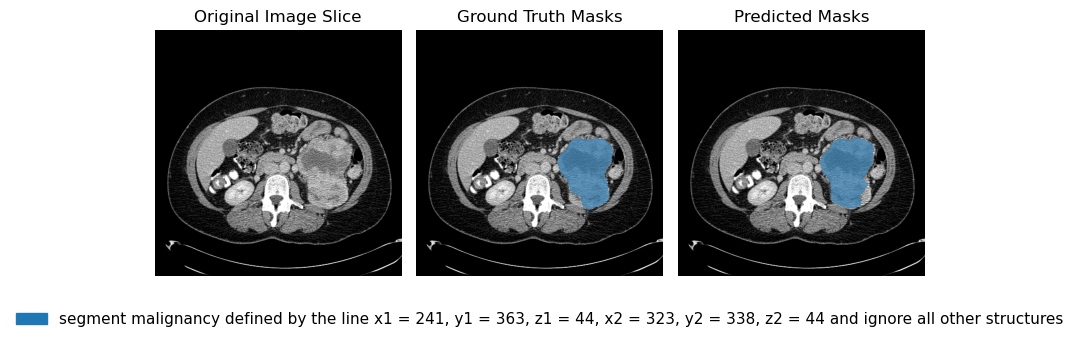

In [174]:
slice_id = 23
slice_image = image[slice_id]
slice_mask = mask_preds[slice_id]
slice_gt   = gt[slice_id]

# rotate = 2
# slice_image = np.rot90(slice_image, k=rotate)
# slice_gt = np.rot90(slice_gt, k=rotate)
# slice_mask = np.rot90(slice_mask, k=rotate)

# flip = True
# if flip:
#     slice_image = np.flip(slice_image, axis=1)
#     slice_gt = np.flip(slice_gt, axis=1)
#     slice_mask = np.flip(slice_mask, axis=1)

# if text_prompts['instance_label'] == 1:
#     # If instance_label is 1, we assume it is a binary mask
#     slice_gt   = slice_gt > 0

# 1) Compute the mapping
unique_ids = np.unique(np.concatenate((slice_mask, slice_gt)))
id_map = {orig_id: new_i for new_i, orig_id in enumerate(unique_ids)}

slice_mask_mapped = np.vectorize(id_map.get)(slice_mask)
slice_gt_mapped   = np.vectorize(id_map.get)(slice_gt)

slice_mask_mapped = np.ma.masked_where(slice_mask_mapped == 0, slice_mask_mapped)
slice_gt_mapped = np.ma.masked_where(slice_gt_mapped == 0, slice_gt_mapped)

# 2) Which IDs to show (drop background=0)
mask_ids = unique_ids[1:]

# 3) Labels for legend
legends = [text_prompts[str(i)] for i in mask_ids if str(i) in text_prompts]
mask_ids = [i for i in mask_ids if str(i) in text_prompts]

# 4) Build a *discrete* colormap of size len(unique_ids)
#    so that cmap(k) gives exactly the k-th color.
cmap = plt.get_cmap('tab20', len(unique_ids)-1)

# 5) Create handles using integer lookup into the discrete cmap
handles = [
    mpatches.Patch(color=cmap(id_map[i]-1), label=txt)
    for i, txt in zip(mask_ids, legends)
]

# 6) Plot
fig, axes = plt.subplots(1, 3, figsize=(8, 3))

axes[0].imshow(slice_image, cmap="gray")
axes[0].set_title("Original Image Slice")
axes[0].axis("off")

axes[1].imshow(slice_image, cmap='gray')
axes[1].imshow(slice_gt_mapped, cmap=cmap, interpolation='nearest', alpha = 0.6)
axes[1].set_title("Ground Truth Masks")
axes[1].axis("off")

axes[2].imshow(slice_image, cmap='gray')
axes[2].imshow(slice_mask_mapped, cmap=cmap, interpolation='nearest', alpha = 0.6)
axes[2].set_title("Predicted Masks")
axes[2].axis("off")

# 7) Shared legend below, single column
fig.legend(handles, legends, loc='lower center', bbox_to_anchor=(0.5, -0.15), ncol=1, frameon=False, fontsize=11)

plt.tight_layout()
plt.subplots_adjust(bottom=0)
plt.show()

### Histogram and Density Visualization

Text(0.5, -0.05, 'segment malignancy defined by the line x1 = 241, y1 = 363, z1 = 44, x2 = 323, y2 = 338, z2 = 44 and ignore all other structures')

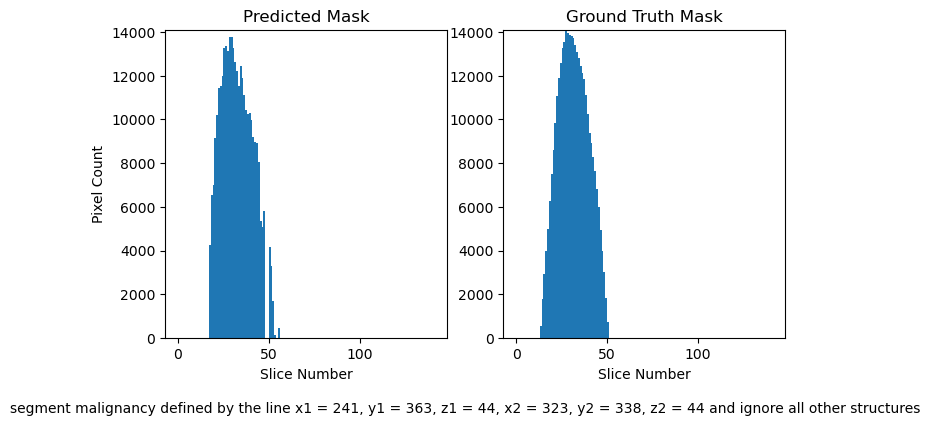

In [175]:
# Get histogram data of number of pixels in each slice 

pred_hist_data = get_hist_data(mask_preds)
gt_hist_data = get_hist_data(gt)

pred_val, pred_weight = zip(*[(key, val) for key, val in pred_hist_data.items()])
gt_val, gt_weight = zip(*[(key, val) for key, val in gt_hist_data.items()])

fig, ax = plt.subplots(1, 2, figsize=(8,4))
ax[0].hist(pred_val, weights = pred_weight, bins = gt.shape[0]-1) 
ax[0].set_ylim(0, max(max(gt_hist_data.values()), max(pred_hist_data.values())))
ax[0].set_title('Predicted Mask')
ax[0].set_ylabel('Pixel Count')
ax[0].set_xlabel('Slice Number')
ax[1].hist(gt_val, weights = gt_weight, bins = gt.shape[0]-1)
ax[1].set_ylim(0, max(max(gt_hist_data.values()), max(pred_hist_data.values())))
ax[1].set_title('Ground Truth Mask')
ax[1].set_xlabel('Slice Number')
plt.figtext(0.5, -0.05, text_prompts['1'], ha='center', va='top')

Text(0.5, -0.05, 'segment malignancy defined by the line x1 = 241, y1 = 363, z1 = 44, x2 = 323, y2 = 338, z2 = 44 and ignore all other structures')

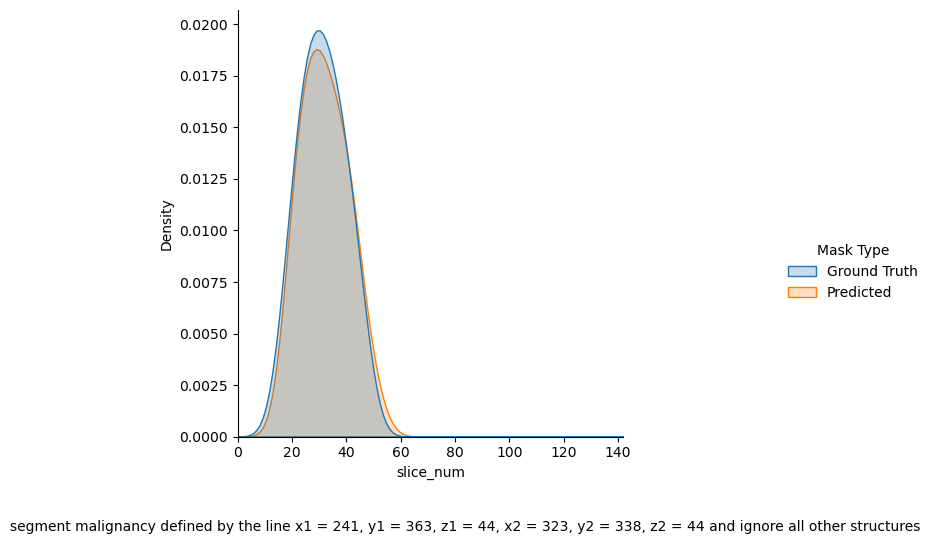

In [176]:
import seaborn as sns 

gt_data = get_hist_data_df(gt)
pred_data = get_hist_data_df(mask_preds)

gt_data["Mask Type"] = "Ground Truth"
pred_data["Mask Type"] = "Predicted"

all_data = pd.concat([gt_data, pred_data], axis = 0).reset_index(drop = True)

plot = sns.displot(data = all_data, 
            x = "slice_num", 
            weights = "pix_count", 
            hue = "Mask Type",
            kind = "kde", 
            fill = True
            )
plot.set(xlim=(0, gt.shape[0]))

plt.figtext(0.5, -0.05, text_prompts['1'], ha='center', va='top')